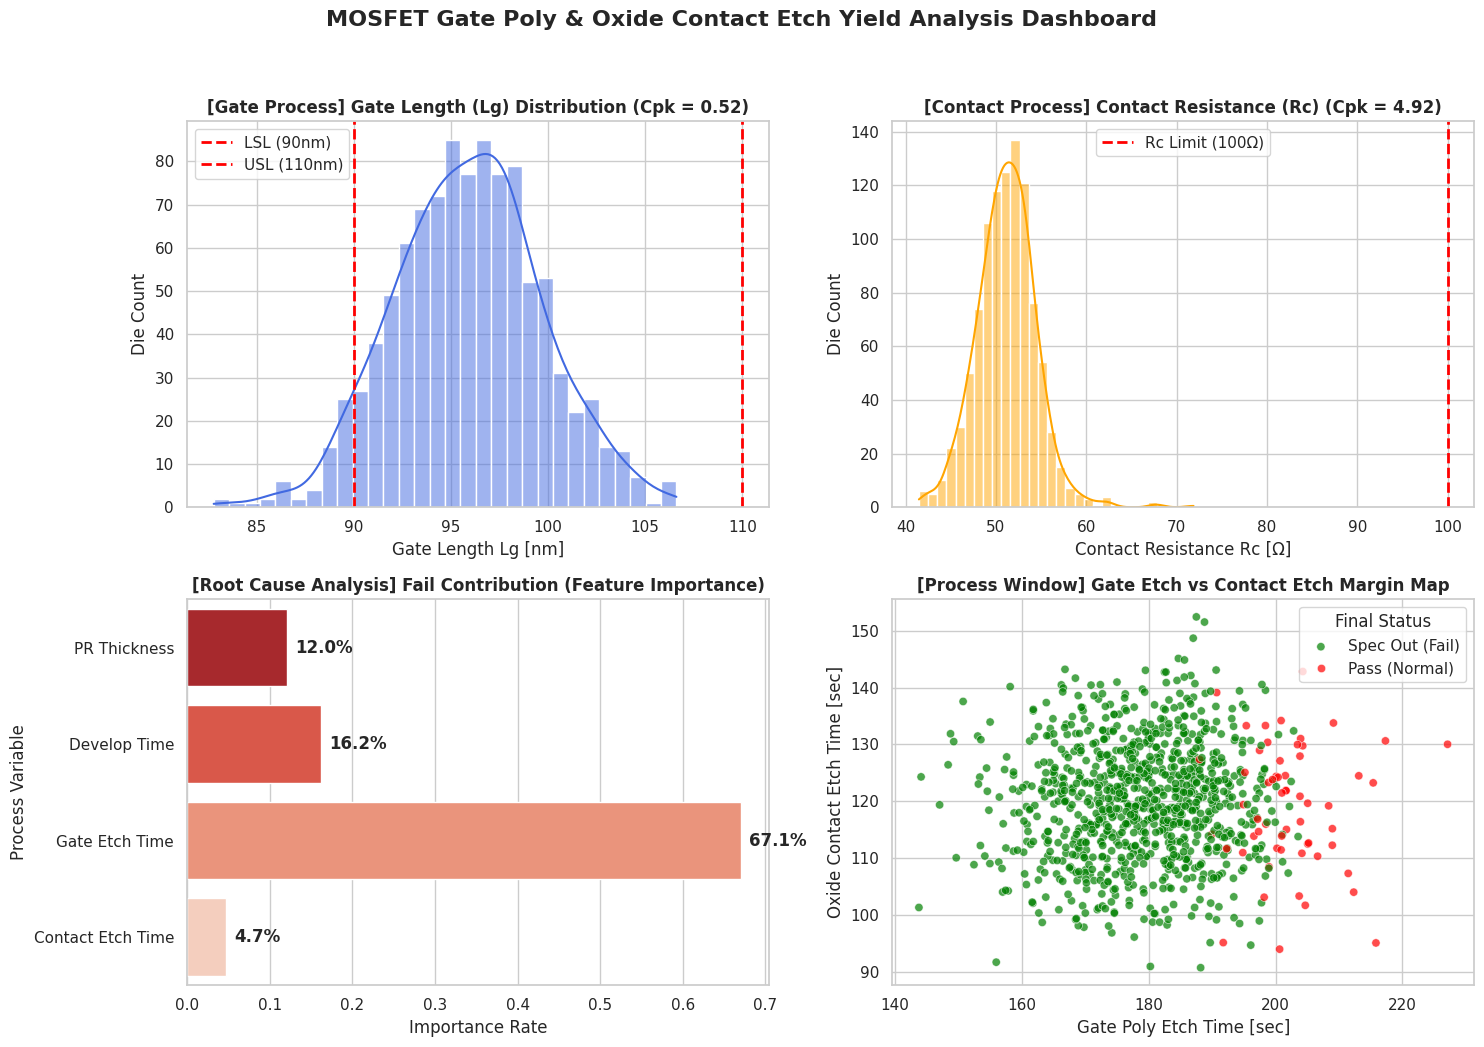

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 전역 그래프 스타일 설정 (폰트 오류 방지용 기본 시스템 폰트 사용)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")


# 1. Monte Carlo 시뮬레이션

np.random.seed(42)
N_SAMPLES = 1000

# 독립 공정 변수 생성
pr_thickness = np.random.normal(loc=120, scale=5, size=N_SAMPLES)
dev_time = np.random.normal(loc=60, scale=3, size=N_SAMPLES)
gate_etch_time = np.random.normal(loc=180, scale=12, size=N_SAMPLES)
contact_etch_time = np.random.normal(loc=120, scale=10, size=N_SAMPLES)

# A. Gate Poly Etch 물리 모델
gate_adi_cd = 150 - (dev_time - 60) * 0.4
gate_etch_bias = (gate_etch_time * 0.3) + (120 - pr_thickness) * 0.15
lg_aci_cd = gate_adi_cd - gate_etch_bias

# RuntimeWarning 방지를 위한 안전한 음수 처리
sce_penalty = np.maximum(0, 90 - lg_aci_cd) ** 1.8
ss_val = 60 + 0.5 * (100 - lg_aci_cd) + sce_penalty
gate_pass = (lg_aci_cd >= 90) & (lg_aci_cd <= 110)

# B. Oxide Contact Etch 물리 모델
contact_cd = 80 + (contact_etch_time - 120) * 0.4 + (dev_time - 60) * 0.2
rc_val = 50 + np.exp(np.maximum(0, (110 - contact_etch_time) * 0.15)) + np.random.normal(0, 3, N_SAMPLES)
contact_pass = (rc_val <= 100) & (contact_cd <= 95)

# C. 최종 통합 수율
final_pass = gate_pass & contact_pass

df = pd.DataFrame({
    'PR_Thickness': pr_thickness,
    'Develop_Time': dev_time,
    'Gate_Etch_Time': gate_etch_time,
    'Contact_Etch_Time': contact_etch_time,
    'Lg_ACI_CD': lg_aci_cd,
    'SS': ss_val,
    'Contact_CD': contact_cd,
    'Contact_Rc': rc_val,
    'Gate_Pass': gate_pass,
    'Contact_Pass': contact_pass,
    'Final_Pass': final_pass
})

# Cpk 산출
cpk_gate = min((110 - df['Lg_ACI_CD'].mean())/(3*df['Lg_ACI_CD'].std()), (df['Lg_ACI_CD'].mean() - 90)/(3*df['Lg_ACI_CD'].std()))
cpk_contact = (100 - df['Contact_Rc'].mean()) / (3 * df['Contact_Rc'].std())


# 2. ML 기반 Root Cause 역추적

X = df[['PR_Thickness', 'Develop_Time', 'Gate_Etch_Time', 'Contact_Etch_Time']]
y = ~df['Final_Pass']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)
importances = model.feature_importances_


# 3. 고화질 통합 대시보드 시각화 (영문 버전)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('MOSFET Gate Poly & Oxide Contact Etch Yield Analysis Dashboard', fontsize=16, fontweight='bold')

# [Plot 1] Gate Poly Etch Feature (Lg Distribution)
sns.histplot(df['Lg_ACI_CD'], kde=True, ax=axes[0, 0], color='royalblue', bins=30)
axes[0, 0].axvline(90, color='red', linestyle='--', linewidth=2, label='LSL (90nm)')
axes[0, 0].axvline(110, color='red', linestyle='--', linewidth=2, label='USL (110nm)')
axes[0, 0].set_title(f'[Gate Process] Gate Length (Lg) Distribution (Cpk = {cpk_gate:.2f})', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Gate Length Lg [nm]')
axes[0, 0].set_ylabel('Die Count')
axes[0, 0].legend()

# [Plot 2] Oxide Contact Etch Feature (Rc Distribution)
sns.histplot(df['Contact_Rc'], kde=True, ax=axes[0, 1], color='orange', bins=30)
axes[0, 1].axvline(100, color='red', linestyle='--', linewidth=2, label='Rc Limit (100Ω)')
axes[0, 1].set_title(f'[Contact Process] Contact Resistance (Rc) (Cpk = {cpk_contact:.2f})', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Contact Resistance Rc [Ω]')
axes[0, 1].set_ylabel('Die Count')
axes[0, 1].legend()

# [Plot 3] ML Feature Importance
feat_df = pd.DataFrame({'Variable': ['PR Thickness', 'Develop Time', 'Gate Etch Time', 'Contact Etch Time'], 'Importance': importances})
sns.barplot(x='Importance', y='Variable', data=feat_df, ax=axes[1, 0], hue='Variable', palette='Reds_r', legend=False)
axes[1, 0].set_title('[Root Cause Analysis] Fail Contribution (Feature Importance)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Importance Rate')
axes[1, 0].set_ylabel('Process Variable')
for idx, val in enumerate(importances):
    axes[1, 0].text(val + 0.01, idx, f'{val*100:.1f}%', va='center', fontweight='bold')

# [Plot 4] Multi-Process Window Map
sns.scatterplot(
    data=df, x='Gate_Etch_Time', y='Contact_Etch_Time', hue='Final_Pass',
    palette={True: 'green', False: 'red'}, alpha=0.7, ax=axes[1, 1]
)
axes[1, 1].set_title('[Process Window] Gate Etch vs Contact Etch Margin Map', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Gate Poly Etch Time [sec]')
axes[1, 1].set_ylabel('Oxide Contact Etch Time [sec]')
axes[1, 1].legend(title='Final Status', labels=['Spec Out (Fail)', 'Pass (Normal)'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()